In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [4]:
df = pd.read_csv(
    "../datasets/customer_ml_dataset_feature_engineered.csv"
)

In [5]:
df.head()

,customer_id,total_sessions,total_orders,total_spend,average_order_value,cart_abandonment_rate,average_discount_used,customer_satisfaction,preferred_device,city,...,purchase_velocity,discount_dependency_score,return_behavior_score,R,F,M,RFM_Score,customer_segment,churn_risk_score,high_risk_customer
0,1000,2,1,1228.72,1228.72,0.50,17.50,3.50,1,204,...,0.333333,5.833333,64.440879,2,3,2,232,At Risk,49.00,0
1,1001,1,0,0.00,1399.00,0.00,0.00,4.00,0,101,...,0.000000,0.000000,50.000000,2,1,1,211,Lost Customers,36.00,0
2,1002,3,0,0.00,1399.00,0.67,3.33,4.00,1,90,...,0.000000,0.000000,83.500000,5,1,1,511,Loyal Customers,62.80,1
3,1003,3,1,1681.96,1681.96,0.00,11.67,4.33,1,87,...,0.250000,2.917500,40.703183,4,3,2,432,Potential Loyalists,26.52,0
4,1004,3,0,0.00,1399.00,0.33,16.67,4.00,1,97,...,0.000000,0.000000,66.500000,3,1,1,311,At Risk,49.20,0


In [6]:
df.shape

(1000, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                1000 non-null   int64  
 1   total_sessions             1000 non-null   int64  
 2   total_orders               1000 non-null   int64  
 3   total_spend                1000 non-null   float64
 4   average_order_value        1000 non-null   float64
 5   cart_abandonment_rate      1000 non-null   float64
 6   average_discount_used      1000 non-null   float64
 7   customer_satisfaction      1000 non-null   float64
 8   preferred_device           1000 non-null   int64  
 9   city                       1000 non-null   int64  
 10  preferred_category         1000 non-null   int64  
 11  total_products_purchased   1000 non-null   int64  
 12  total_pages_viewed         1000 non-null   int64  
 13  average_time_on_site       1000 non-null   float64
 14  tota

In [8]:
X = df.drop(
    columns=[
        "customer_id",
        "churn"
    ]
)

y = df["churn"]

In [9]:
rf_model = joblib.load(
    "../models/random_forest.pkl"
)

xgb_model = joblib.load(
    "../models/xgboost.pkl"
)

In [10]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [11]:
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

In [12]:
rf_importance.head(15)

,Feature,Importance
4,cart_abandonment_rate,0.092618
14,preferred_payment_method,0.086980
16,recency,0.053367
12,average_time_on_site,0.051224
27,churn_risk_score,0.050843
15,rn,0.047302
9,preferred_category,0.045283
8,city,0.042921
25,RFM_Score,0.041611
11,total_pages_viewed,0.039721


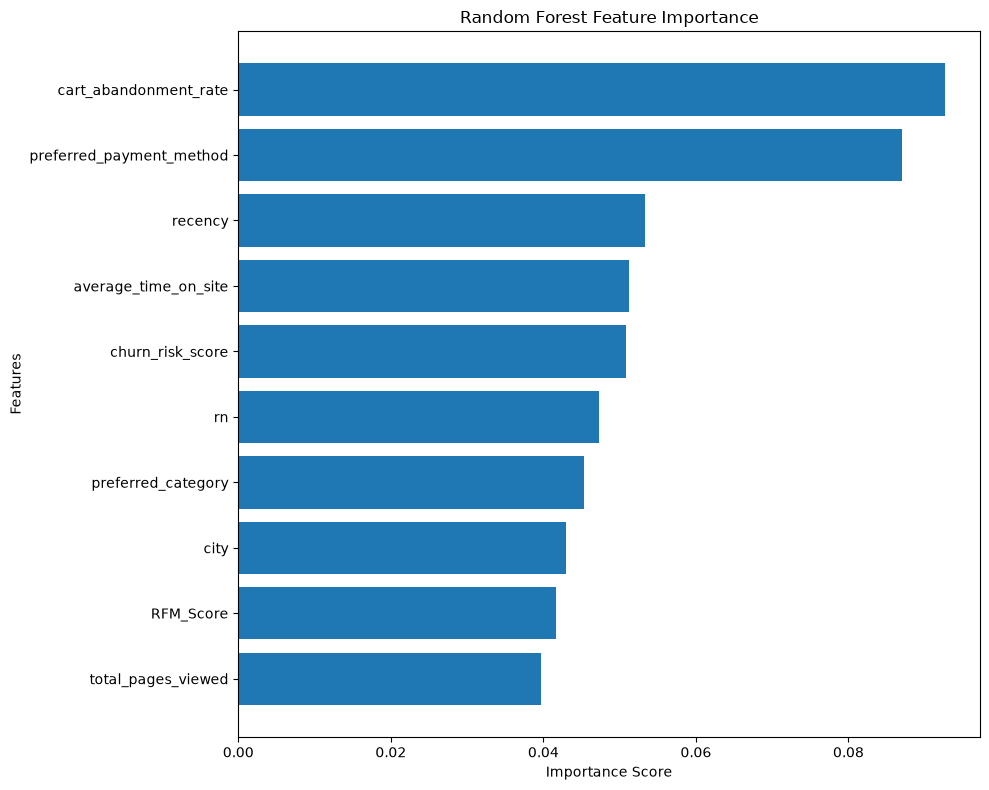

In [13]:
plt.figure(figsize=(10,8))

plt.barh(
    rf_importance["Feature"].head(10),
    rf_importance["Importance"].head(10)
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../images/random_forest_feature_importance.png"
)

plt.show()

In [14]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

In [15]:
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

In [16]:
xgb_importance.head(15)

,Feature,Importance
28,high_risk_customer,0.084372
14,preferred_payment_method,0.063456
7,preferred_device,0.053254
4,cart_abandonment_rate,0.052077
18,monetary,0.051599
0,total_sessions,0.048952
20,discount_dependency_score,0.046193
22,R,0.045490
26,customer_segment,0.041572
25,RFM_Score,0.038947


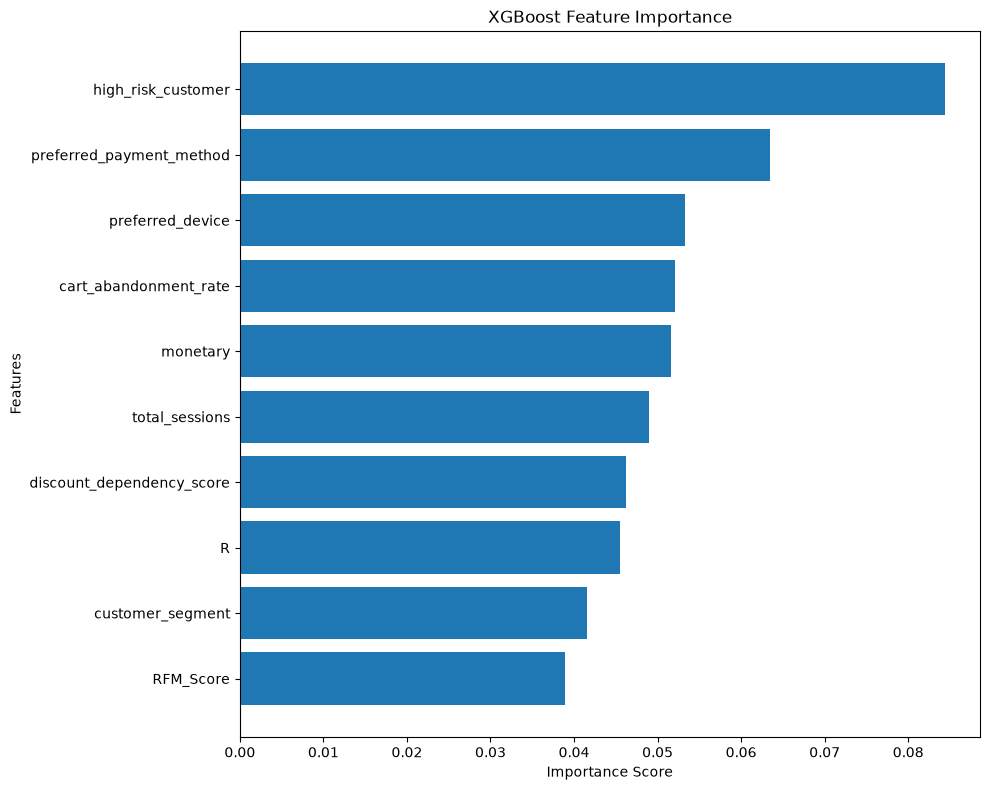

In [17]:
plt.figure(figsize=(10,8))

plt.barh(
    xgb_importance["Feature"].head(10),
    xgb_importance["Importance"].head(10)
)

plt.title(
    "XGBoost Feature Importance"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../images/xgboost_feature_importance.png"
)

plt.show()

In [18]:
top_rf_features = rf_importance.head(10)

top_rf_features

,Feature,Importance
4,cart_abandonment_rate,0.092618
14,preferred_payment_method,0.086980
16,recency,0.053367
12,average_time_on_site,0.051224
27,churn_risk_score,0.050843
15,rn,0.047302
9,preferred_category,0.045283
8,city,0.042921
25,RFM_Score,0.041611
11,total_pages_viewed,0.039721


In [19]:
top_xgb_features = xgb_importance.head(10)

top_xgb_features

,Feature,Importance
28,high_risk_customer,0.084372
14,preferred_payment_method,0.063456
7,preferred_device,0.053254
4,cart_abandonment_rate,0.052077
18,monetary,0.051599
0,total_sessions,0.048952
20,discount_dependency_score,0.046193
22,R,0.045490
26,customer_segment,0.041572
25,RFM_Score,0.038947


In [20]:
business_insights = pd.DataFrame({
    "Feature": [
        "cart_abandonment_rate",
        "purchase_velocity",
        "customer_satisfaction",
        "frequency",
        "monetary",
        "discount_dependency_score",
        "recency",
        "return_behavior_score"
    ],
    "Business Interpretation": [
        "Customers abandoning carts frequently are likely to churn.",
        "Customers purchasing less frequently have higher churn risk.",
        "Low satisfaction strongly increases churn probability.",
        "Low order frequency indicates weak customer engagement.",
        "Lower spending customers churn more often.",
        "Customers relying heavily on discounts have weaker loyalty.",
        "Inactive customers are more likely to leave.",
        "Negative shopping behaviour increases churn risk."
    ]
})

business_insights

,Feature,Business Interpretation
0,cart_abandonment_rate,Customers abandoning carts frequently are like...
1,purchase_velocity,Customers purchasing less frequently have high...
2,customer_satisfaction,Low satisfaction strongly increases churn prob...
3,frequency,Low order frequency indicates weak customer en...
4,monetary,Lower spending customers churn more often.
5,discount_dependency_score,Customers relying heavily on discounts have we...
6,recency,Inactive customers are more likely to leave.
7,return_behavior_score,Negative shopping behaviour increases churn risk.


In [21]:
rf_importance.to_csv(
    "../datasets/random_forest_feature_importance.csv",
    index=False
)

xgb_importance.to_csv(
    "../datasets/xgboost_feature_importance.csv",
    index=False
)

In [22]:
print(
"""
Top Churn Drivers:

1. Cart Abandonment Rate
2. Purchase Velocity
3. Customer Satisfaction
4. Frequency
5. Monetary Value
6. Discount Dependency Score
7. Recency
8. Return Behavior Score
"""
)


Top Churn Drivers:

1. Cart Abandonment Rate
2. Purchase Velocity
3. Customer Satisfaction
4. Frequency
5. Monetary Value
6. Discount Dependency Score
7. Recency
8. Return Behavior Score

